Page 1 done
Page 2 done
Page 3 done


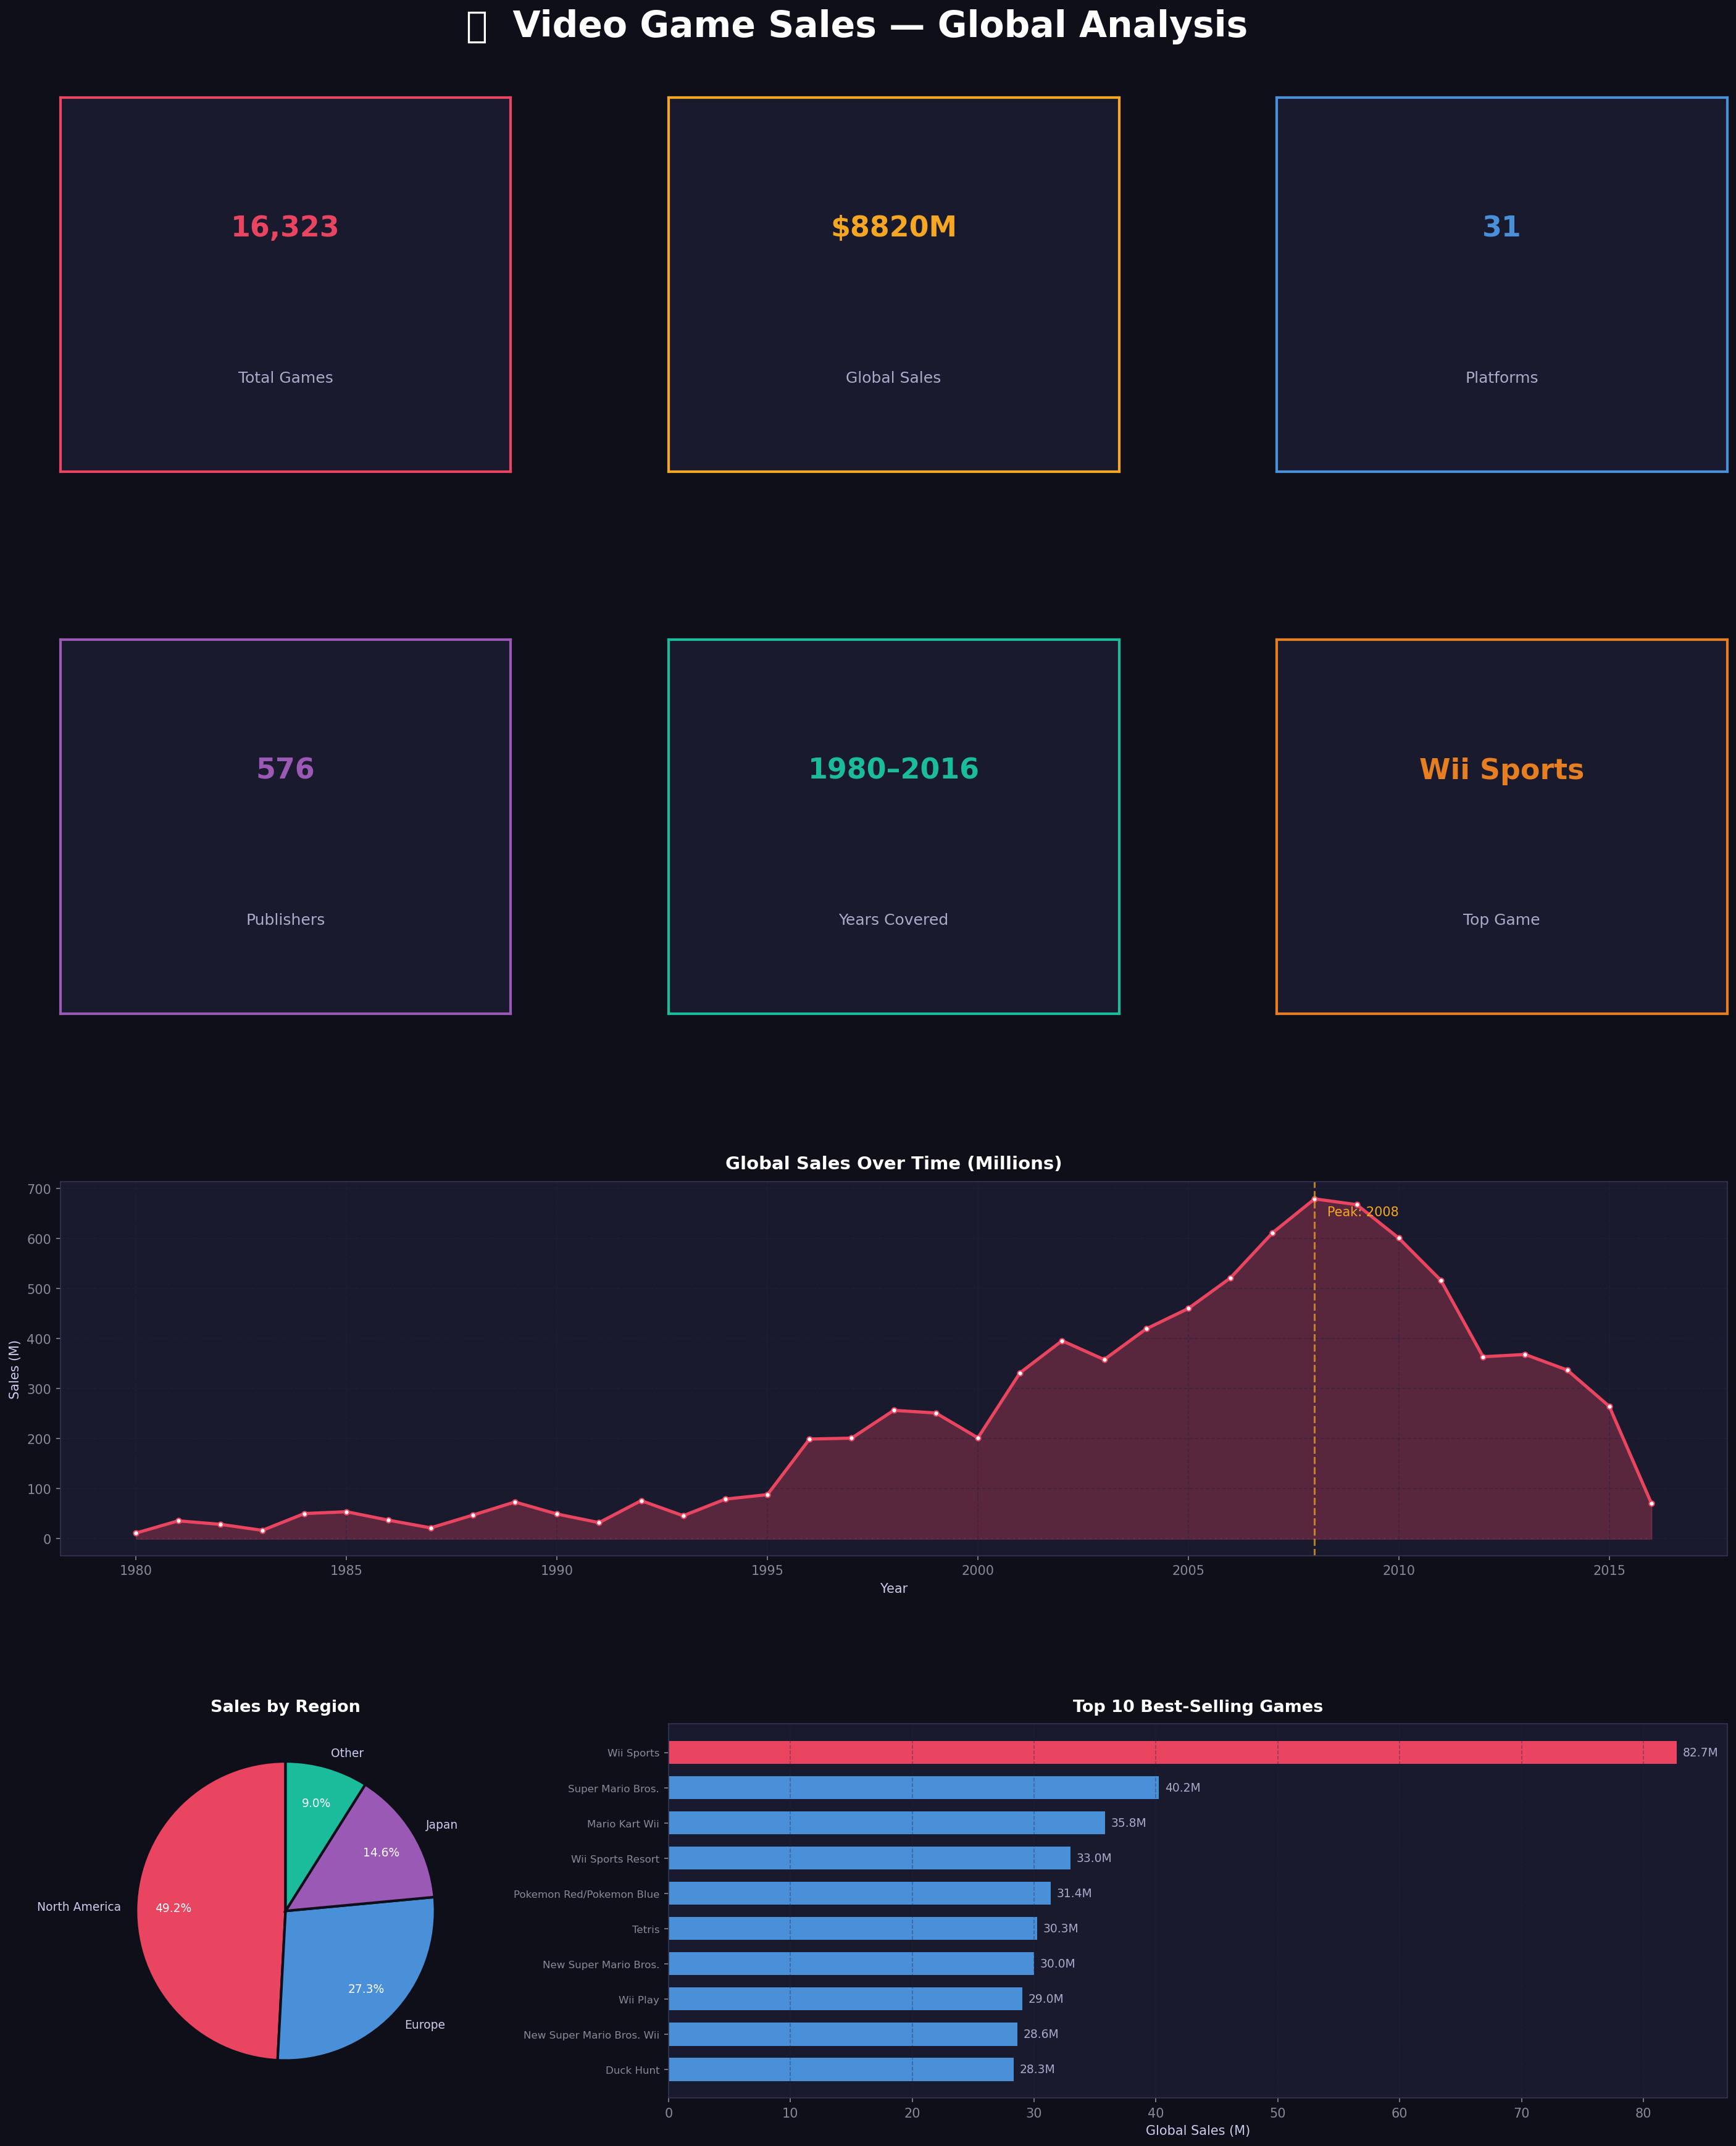

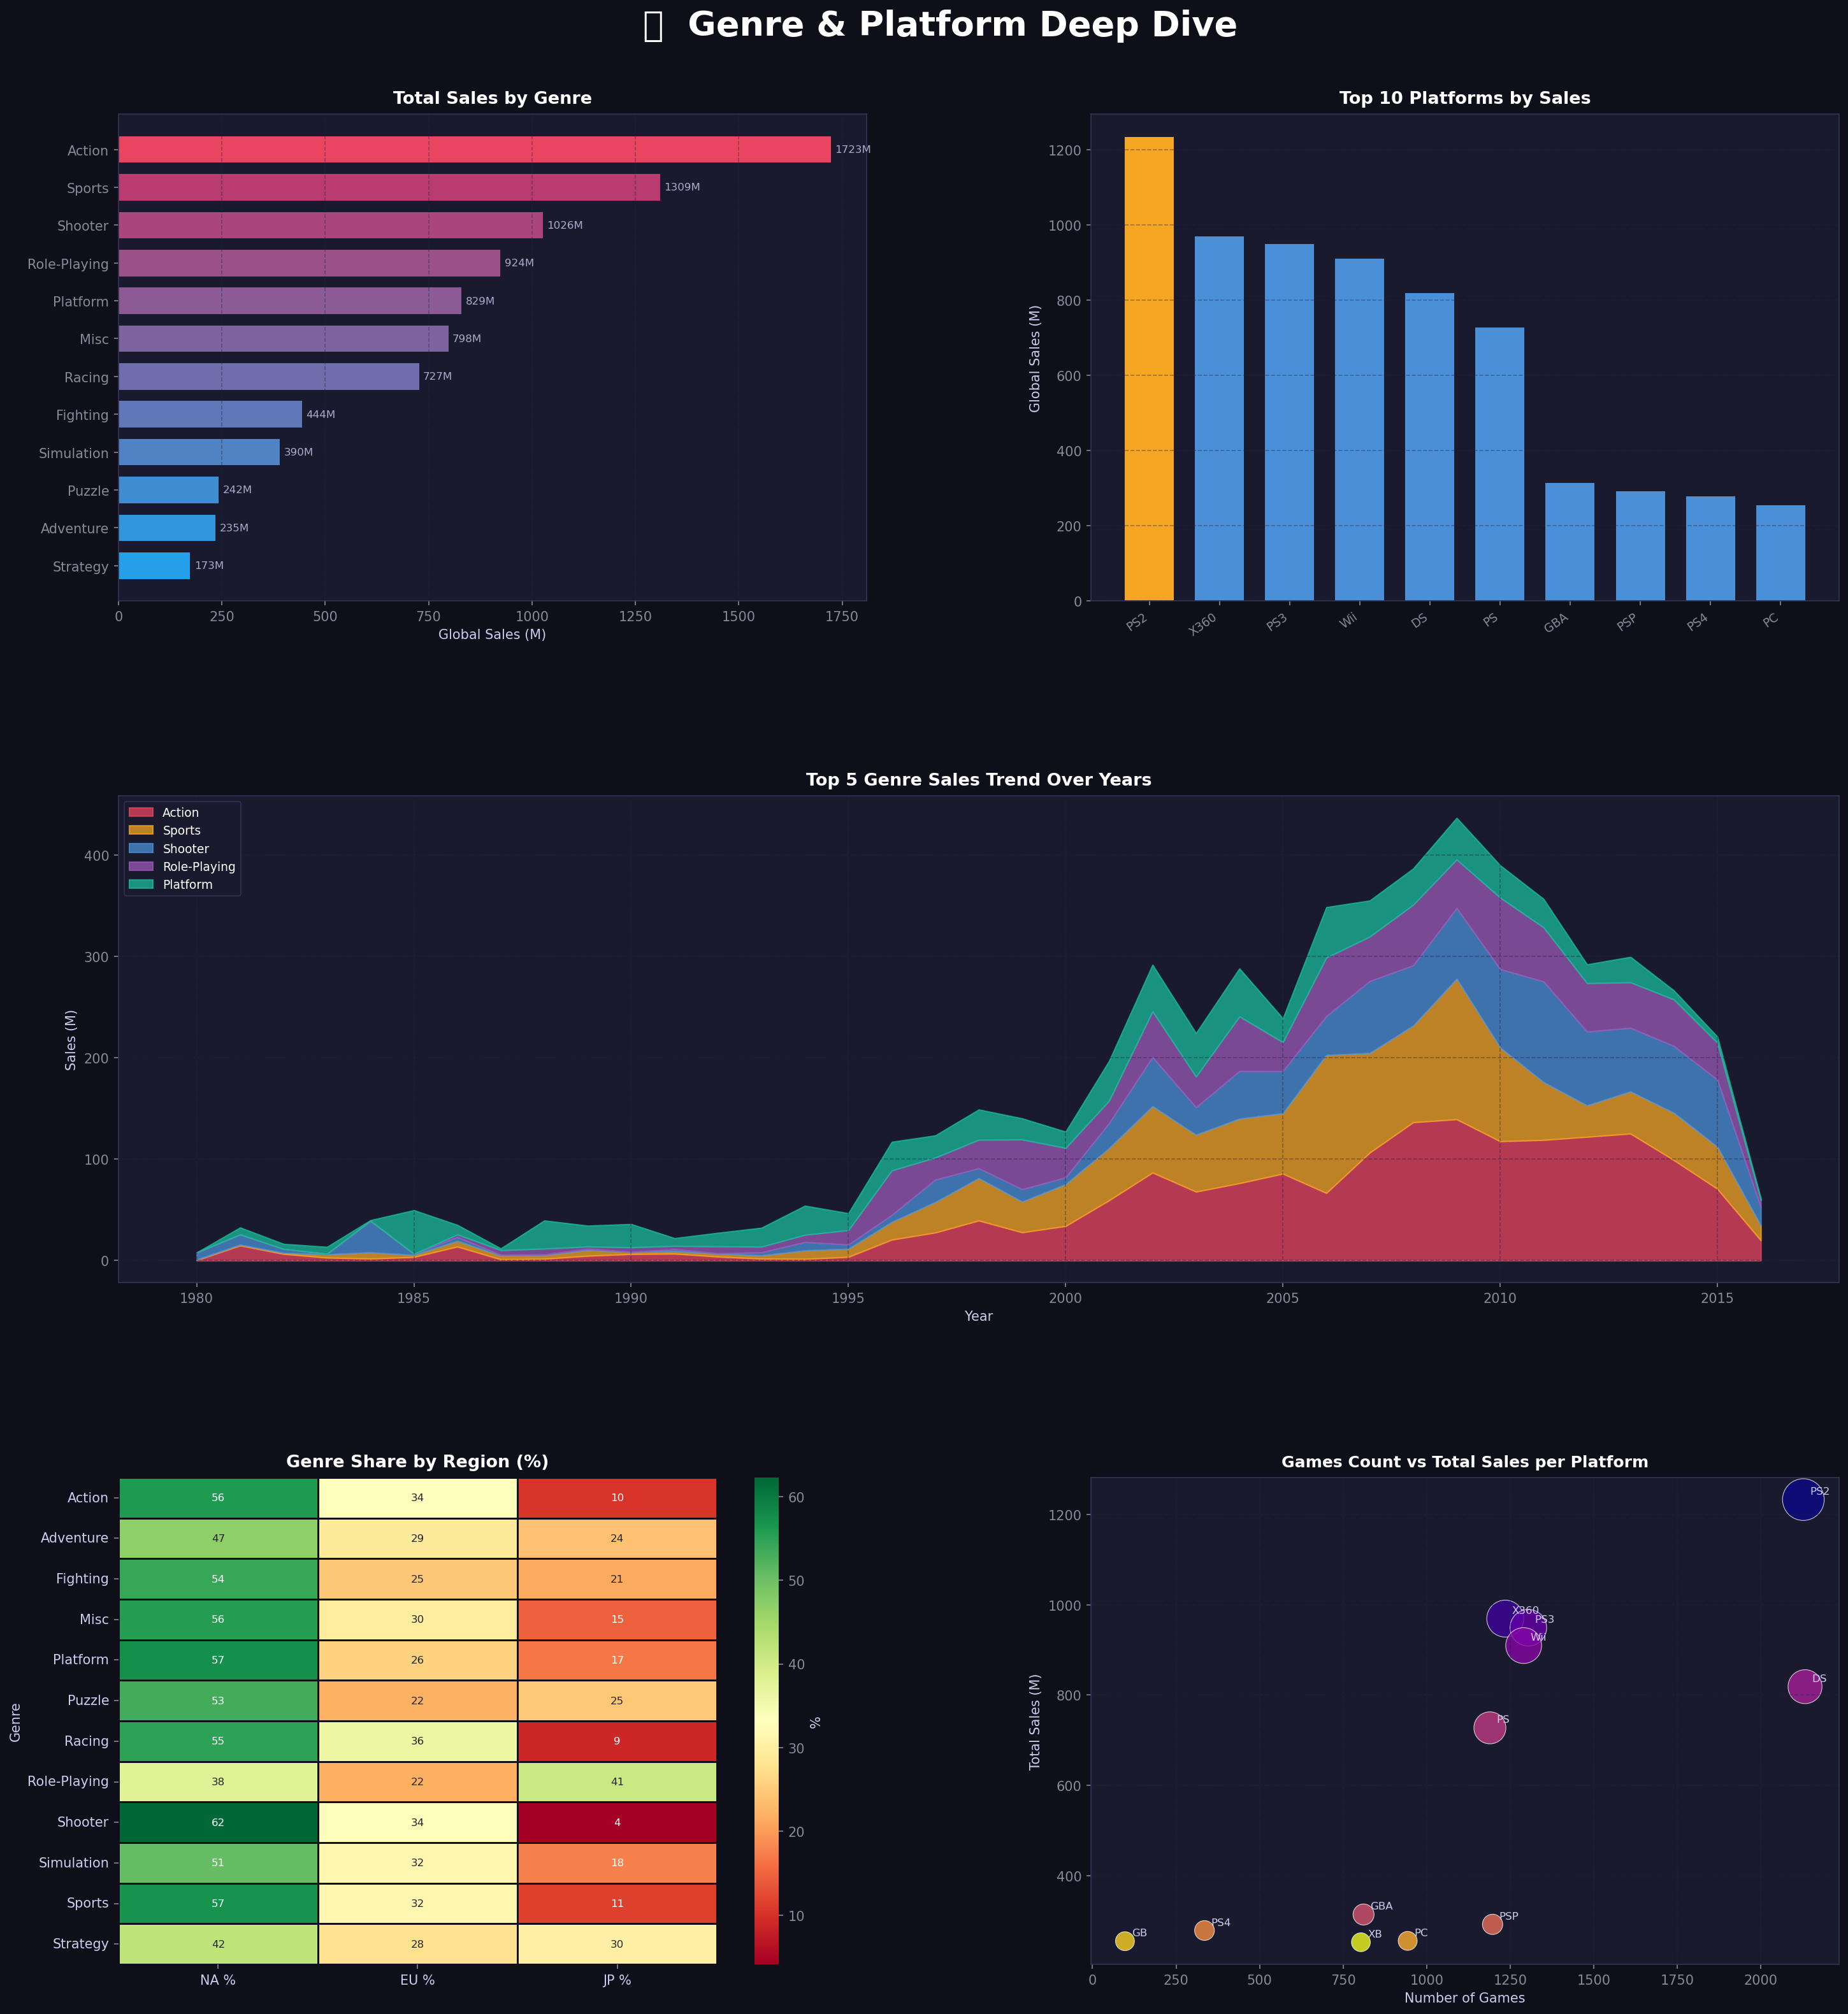

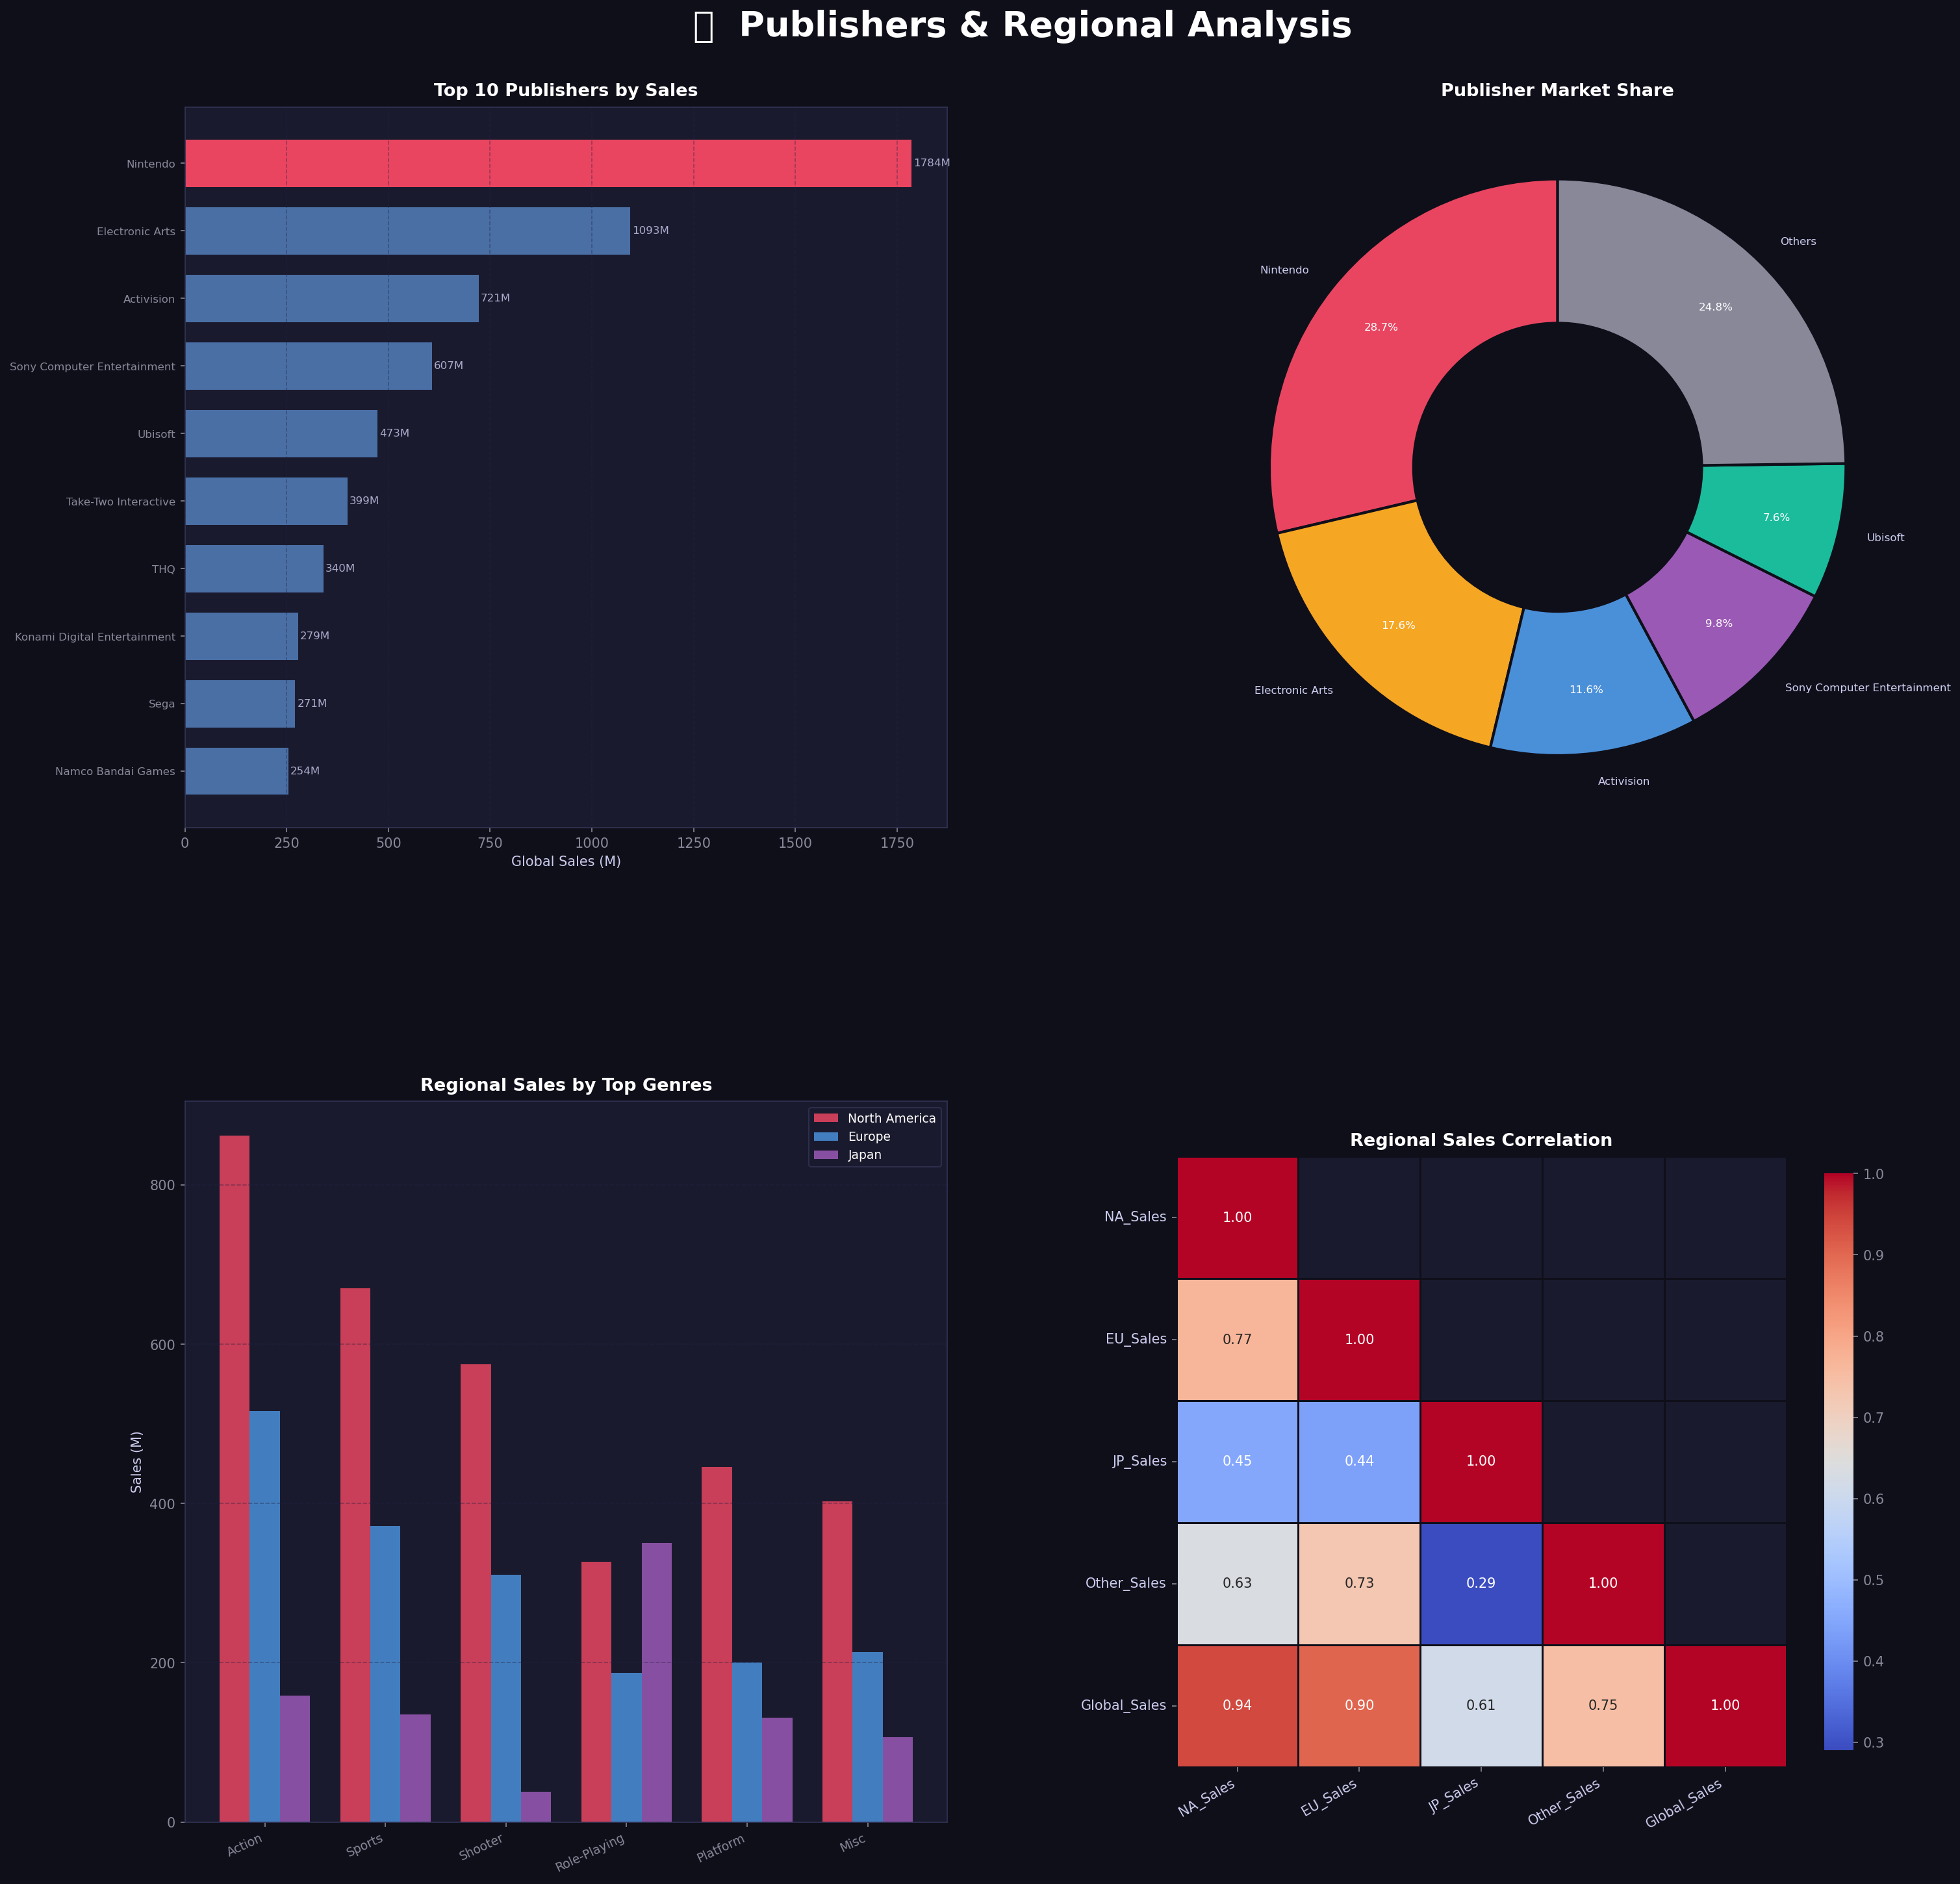

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import os

OUTPUT_DIR = r'D:\paython\archive\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Style settings
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#333355'
plt.rcParams['axes.labelcolor']  = '#ccccee'
plt.rcParams['xtick.color']      = '#888899'
plt.rcParams['ytick.color']      = '#888899'
plt.rcParams['text.color']       = '#eeeeff'
plt.rcParams['grid.color']       = '#222244'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'DejaVu Sans'

COLORS = ['#e94560','#0f3460','#533483','#16213e',
          '#e94560','#f5a623','#7ed321','#4a90d9',
          '#9b59b6','#1abc9c','#e67e22','#e74c3c']

ACCENT  = '#e94560'
ACCENT2 = '#f5a623'
ACCENT3 = '#4a90d9'
BG_DARK = '#0f0f1a'
BG_MID  = '#1a1a2e'

# data uploadings
df = pd.read_csv(r'D:\paython\archive\vgsales.csv')
df.dropna(subset=['Year'], inplace=True)
df['Year'] = df['Year'].astype(int)
df = df[df['Year'] <= 2016]

# pre calculations
genre_sales      = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
platform_sales   = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
publisher_sales  = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
year_sales       = df.groupby('Year')['Global_Sales'].sum()
top10_games      = df.nlargest(10, 'Global_Sales')[['Name','Platform','Genre','Global_Sales']]
region_totals    = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
region_labels    = ['North America','Europe','Japan','Other']
genre_region     = df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum()
platform_count   = df.groupby('Platform')['Name'].count().sort_values(ascending=False).head(10)
yearly_genre     = df.groupby(['Year','Genre'])['Global_Sales'].sum().unstack(fill_value=0)
top5_genres      = genre_sales.head(5).index.tolist()

# page 1
fig1 = plt.figure(figsize=(20, 24), facecolor=BG_DARK)
fig1.suptitle('🎮  Video Game Sales — Global Analysis',
              fontsize=28, fontweight='bold', color='white',
              y=0.98, va='top')

gs1 = gridspec.GridSpec(4, 3, figure=fig1,
                        hspace=0.45, wspace=0.35,
                        top=0.94, bottom=0.04,
                        left=0.07, right=0.97)

#  KPI cards (row 0) 
kpis = [
    ('Total Games',    f"{len(df):,}",             ACCENT),
    ('Global Sales',   f"${df['Global_Sales'].sum():.0f}M",  ACCENT2),
    ('Platforms',      str(df['Platform'].nunique()), ACCENT3),
    ('Publishers',     str(df['Publisher'].nunique()), '#9b59b6'),
    ('Years Covered',  f"{df['Year'].min()}–{df['Year'].max()}", '#1abc9c'),
    ('Top Game',       'Wii Sports',               '#e67e22'),
]
for i, (title, value, color) in enumerate(kpis):
    ax = fig1.add_subplot(gs1[0, i % 3]) if i < 3 else None
    if i >= 3:
        ax = fig1.add_subplot(gs1[1, i - 3])
    ax.set_facecolor(BG_MID)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=12, color='#aaaacc',
            transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

#  Sales over time (row 2) 
ax_time = fig1.add_subplot(gs1[2, :])
ax_time.fill_between(year_sales.index, year_sales.values,
                     alpha=0.3, color=ACCENT)
ax_time.plot(year_sales.index, year_sales.values,
             color=ACCENT, linewidth=2.5, marker='o',
             markersize=4, markerfacecolor='white')
peak_year = year_sales.idxmax()
ax_time.axvline(peak_year, color=ACCENT2, linestyle='--', alpha=0.7, linewidth=1.5)
ax_time.text(peak_year + 0.3, year_sales.max() * 0.95,
             f'Peak: {peak_year}', color=ACCENT2, fontsize=10)
ax_time.set_title('Global Sales Over Time (Millions)', fontsize=14,
                  fontweight='bold', color='white', pad=10)
ax_time.set_xlabel('Year'); ax_time.set_ylabel('Sales (M)')
ax_time.grid(True); ax_time.set_facecolor(BG_MID)

#  Regional pie (row 3, col 0) 
ax_pie = fig1.add_subplot(gs1[3, 0])
wedge_colors = [ACCENT, ACCENT3, '#9b59b6', '#1abc9c']
wedges, texts, autotexts = ax_pie.pie(
    region_totals.values, labels=region_labels,
    colors=wedge_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor=BG_DARK, linewidth=2))
for at in autotexts:
    at.set_fontsize(9); at.set_color('white')
for t in texts:
    t.set_color('#ccccee'); t.set_fontsize(9)
ax_pie.set_title('Sales by Region', fontsize=13,
                 fontweight='bold', color='white', pad=10)
ax_pie.set_facecolor(BG_MID)

#  Top 10 games (row 3, col 1-2) 
ax_top = fig1.add_subplot(gs1[3, 1:])
colors_bar = [ACCENT if i == 0 else ACCENT3 for i in range(10)]
bars = ax_top.barh(top10_games['Name'][::-1],
                   top10_games['Global_Sales'][::-1],
                   color=colors_bar[::-1], edgecolor='none',
                   height=0.65)
for bar, val in zip(bars, top10_games['Global_Sales'][::-1]):
    ax_top.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}M', va='center', fontsize=9, color='#aaaacc')
ax_top.set_title('Top 10 Best-Selling Games', fontsize=13,
                 fontweight='bold', color='white', pad=10)
ax_top.set_xlabel('Global Sales (M)')
ax_top.set_facecolor(BG_MID); ax_top.grid(True, axis='x')
plt.setp(ax_top.get_yticklabels(), fontsize=8)

plt.savefig(os.path.join(OUTPUT_DIR, 'page1_overview.png'),
            dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print("Page 1 done")

#page 2
fig2 = plt.figure(figsize=(20, 22), facecolor=BG_DARK)
fig2.suptitle('🎮  Genre & Platform Deep Dive',
              fontsize=26, fontweight='bold', color='white',
              y=0.98, va='top')

gs2 = gridspec.GridSpec(3, 2, figure=fig2,
                        hspace=0.4, wspace=0.3,
                        top=0.93, bottom=0.05,
                        left=0.07, right=0.97)

#  Genre bar 
ax_g = fig2.add_subplot(gs2[0, 0])
bar_colors = [ACCENT if i == 0 else f'#{int(200-i*15):02x}{int(50+i*10):02x}{int(100+i*12):02x}'
              for i in range(len(genre_sales))]
ax_g.barh(genre_sales.index[::-1], genre_sales.values[::-1],
          color=bar_colors[::-1], edgecolor='none', height=0.7)
for i, (idx, val) in enumerate(zip(genre_sales.index[::-1], genre_sales.values[::-1])):
    ax_g.text(val + 10, i, f'{val:.0f}M', va='center', fontsize=8, color='#aaaacc')
ax_g.set_title('Total Sales by Genre', fontsize=13, fontweight='bold', color='white', pad=8)
ax_g.set_xlabel('Global Sales (M)')
ax_g.set_facecolor(BG_MID); ax_g.grid(True, axis='x')

# Platform bar 
ax_p = fig2.add_subplot(gs2[0, 1])
p_colors = [ACCENT2 if i == 0 else ACCENT3 for i in range(len(platform_sales))]
ax_p.bar(platform_sales.index, platform_sales.values,
         color=p_colors, edgecolor='none', width=0.7)
ax_p.set_title('Top 10 Platforms by Sales', fontsize=13, fontweight='bold', color='white', pad=8)
ax_p.set_ylabel('Global Sales (M)')
ax_p.set_facecolor(BG_MID); ax_p.grid(True, axis='y')
plt.setp(ax_p.get_xticklabels(), rotation=35, ha='right', fontsize=9)

#  Stacked area: genre trends 
ax_area = fig2.add_subplot(gs2[1, :])
area_colors = [ACCENT, ACCENT2, ACCENT3, '#9b59b6', '#1abc9c']
bottom = np.zeros(len(yearly_genre))
for genre, color in zip(top5_genres, area_colors):
    vals = yearly_genre[genre].values if genre in yearly_genre.columns else np.zeros(len(yearly_genre))
    ax_area.fill_between(yearly_genre.index, bottom, bottom + vals,
                         alpha=0.75, color=color, label=genre)
    bottom += vals
ax_area.set_title('Top 5 Genre Sales Trend Over Years', fontsize=13,
                  fontweight='bold', color='white', pad=8)
ax_area.set_xlabel('Year'); ax_area.set_ylabel('Sales (M)')
ax_area.legend(loc='upper left', fontsize=9,
               facecolor=BG_MID, edgecolor='#333355', labelcolor='white')
ax_area.set_facecolor(BG_MID); ax_area.grid(True)

#  Genre × Region heatmap 
ax_heat = fig2.add_subplot(gs2[2, 0])
heat_data = genre_region.div(genre_region.sum(axis=1), axis=0) * 100
heat_data.columns = ['NA %','EU %','JP %']
sns.heatmap(heat_data, ax=ax_heat, cmap='RdYlGn', annot=True,
            fmt='.0f', linewidths=0.5, linecolor=BG_DARK,
            cbar_kws={'label': '%'}, annot_kws={'size': 8})
ax_heat.set_title('Genre Share by Region (%)', fontsize=13,
                  fontweight='bold', color='white', pad=8)
ax_heat.set_facecolor(BG_MID)
plt.setp(ax_heat.get_xticklabels(), color='#ccccee')
plt.setp(ax_heat.get_yticklabels(), color='#ccccee', rotation=0)

#  Platform game count vs sales bubble 
ax_bub = fig2.add_subplot(gs2[2, 1])
top_plat = df.groupby('Platform').agg(
    games=('Name','count'),
    sales=('Global_Sales','sum')
).sort_values('sales', ascending=False).head(12)
scatter = ax_bub.scatter(top_plat['games'], top_plat['sales'],
                         s=top_plat['sales']*0.8,
                         c=range(len(top_plat)),
                         cmap='plasma', alpha=0.8, edgecolors='white',
                         linewidths=0.5)
for plat, row in top_plat.iterrows():
    ax_bub.annotate(plat, (row['games'], row['sales']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=8, color='#ccccee')
ax_bub.set_title('Games Count vs Total Sales per Platform',
                 fontsize=12, fontweight='bold', color='white', pad=8)
ax_bub.set_xlabel('Number of Games')
ax_bub.set_ylabel('Total Sales (M)')
ax_bub.set_facecolor(BG_MID); ax_bub.grid(True)

plt.savefig(os.path.join(OUTPUT_DIR, 'page2_genre_platform.png'),
            dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print("Page 2 done")


# page 3

fig3 = plt.figure(figsize=(20, 20), facecolor=BG_DARK)
fig3.suptitle('🎮  Publishers & Regional Analysis',
              fontsize=26, fontweight='bold', color='white',
              y=0.98, va='top')

gs3 = gridspec.GridSpec(2, 2, figure=fig3,
                        hspace=0.38, wspace=0.3,
                        top=0.93, bottom=0.05,
                        left=0.07, right=0.97)

# Top 10 publishers 
ax_pub = fig3.add_subplot(gs3[0, 0])
pub_colors = [ACCENT if i == 0 else '#4a6fa5' for i in range(len(publisher_sales))]
bars = ax_pub.barh(publisher_sales.index[::-1],
                   publisher_sales.values[::-1],
                   color=pub_colors[::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, publisher_sales.values[::-1]):
    ax_pub.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}M', va='center', fontsize=8, color='#aaaacc')
ax_pub.set_title('Top 10 Publishers by Sales', fontsize=13,
                 fontweight='bold', color='white', pad=8)
ax_pub.set_xlabel('Global Sales (M)')
ax_pub.set_facecolor(BG_MID); ax_pub.grid(True, axis='x')
plt.setp(ax_pub.get_yticklabels(), fontsize=8)

#  Publisher market share donut 
ax_don = fig3.add_subplot(gs3[0, 1])
top5_pub   = publisher_sales.head(5)
others_sum = publisher_sales[5:].sum()
donut_vals = list(top5_pub.values) + [others_sum]
donut_lbls = list(top5_pub.index) + ['Others']
donut_clrs = [ACCENT, ACCENT2, ACCENT3, '#9b59b6', '#1abc9c', '#888899']
wedges, texts, autotexts = ax_don.pie(
    donut_vals, labels=donut_lbls, colors=donut_clrs,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.5, edgecolor=BG_DARK, linewidth=2))
for at in autotexts:
    at.set_fontsize(8); at.set_color('white')
for t in texts:
    t.set_color('#ccccee'); t.set_fontsize(8)
ax_don.set_title('Publisher Market Share', fontsize=13,
                 fontweight='bold', color='white', pad=8)
ax_don.set_facecolor(BG_MID)

#  Regional grouped bar by top genre 
ax_reg = fig3.add_subplot(gs3[1, 0])
top6_genres = genre_sales.head(6).index.tolist()
gr = df[df['Genre'].isin(top6_genres)].groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum()
gr = gr.loc[top6_genres]
x     = np.arange(len(gr))
width = 0.25
ax_reg.bar(x - width, gr['NA_Sales'], width, label='North America', color=ACCENT,   alpha=0.85)
ax_reg.bar(x,          gr['EU_Sales'], width, label='Europe',        color=ACCENT3,  alpha=0.85)
ax_reg.bar(x + width,  gr['JP_Sales'], width, label='Japan',         color='#9b59b6',alpha=0.85)
ax_reg.set_xticks(x)
ax_reg.set_xticklabels(top6_genres, rotation=25, ha='right', fontsize=9)
ax_reg.set_title('Regional Sales by Top Genres', fontsize=13,
                 fontweight='bold', color='white', pad=8)
ax_reg.set_ylabel('Sales (M)')
ax_reg.legend(facecolor=BG_MID, edgecolor='#333355',
              labelcolor='white', fontsize=9)
ax_reg.set_facecolor(BG_MID); ax_reg.grid(True, axis='y')

#  Correlation heatmap 
ax_cor = fig3.add_subplot(gs3[1, 1])
corr_df = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, ax=ax_cor, mask=mask, cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor=BG_DARK, square=True,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
ax_cor.set_title('Regional Sales Correlation', fontsize=13,
                 fontweight='bold', color='white', pad=8)
ax_cor.set_facecolor(BG_MID)
plt.setp(ax_cor.get_xticklabels(), color='#ccccee', rotation=30, ha='right')
plt.setp(ax_cor.get_yticklabels(), color='#ccccee', rotation=0)

plt.savefig(os.path.join(OUTPUT_DIR, 'page3_publishers_regional.png'),
            dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print("Page 3 done")
#display dashboard
from IPython.display import Image, display

display(Image(filename=r"D:\paython\archive\outputs\page1_overview.png"))
display(Image(filename=r"D:\paython\archive\outputs\page2_genre_platform.png"))
display(Image(filename=r"D:\paython\archive\outputs\page3_publishers_regional.png"))